# Paper IV Methodology with Public Data

This notebook presents the Paper IV analysis methodology with:

- `data/DS2_wide.xlsx`: public synthetic DS2 training data adapted to the 22-input + 2-output Paper IV feature layout.
- `data/D3.xlsx`: public 136-row PCM-emulated test set in the same 22+2 layout.
- `data/D3_NaMo.xlsx`: NaMo predictions for the 136 D3 rows, stored separately from the measured feature/target table.

The notebook follows the Paper IV methodology: 
- NaMo test-set evaluation
- XGBoost training on DS2_wide
- adaptive coefficient calculation
- hybrid prediction
- repeated random-seed evaluation

## 1. Setup

Import dependencies, define file paths, and configure plotting.

In [23]:
from pathlib import Path
from datetime import datetime as dt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import xgboost as xgb
from tqdm import tqdm

from coeff_field import build_coeff_model, coefficient_for_point

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.expand_frame_repr", False)
pd.set_option("max_colwidth", 800)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 150
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats("retina")

DATA_DIR = Path("data")
DS2_FILE = DATA_DIR / "DS2_wide.xlsx"
D3_FILE = DATA_DIR / "D3.xlsx"
D3_NAMO_FILE = DATA_DIR / "D3_NaMo.xlsx"


## 2. Feature schema and helper functions

Define the 22-input feature layout, target columns, coefficient-space variables, and basic metric utilities.

In [2]:
FEATURE_COLS = [
    "Mg", "Si", "Fe", "Mn", "Cu", "Cr",
    "T4", "T5", "T6", "T7", "T8", "T9", "T10", "T11",
    "t4_5", "t5_6", "t6_7", "t7_8", "t8_9", "t9_10", "t10_11",
    "Scheil",
]
Y_COLS = ["Rp0.2 [MPa]", "Rm [MPa]"]
COEFF_COLS = ["Mg", "Si", "Ageing_holding_temperature", "Scheil"]


def ageing_holding_temperature(df):
    # Reconstruct the Paper IV coefficient-model ageing temperature helper.
    values = []
    for _, row in df.iterrows():
        candidates = []
        for i in range(7, 11):
            t_col = f"T{i}"
            next_t_col = f"T{i + 1}"
            dt_col = f"t{i}_{i + 1}"
            if row[t_col] == row[next_t_col]:
                candidates.append((float(row[dt_col]), float(row[t_col])))
        if candidates:
            values.append(max(candidates, key=lambda item: item[0])[1])
        else:
            values.append(float(row[["T7", "T8", "T9", "T10", "T11"]].max()))
    return values


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

## 3. Load DS2-wide, D3, and NaMo estimates

Load the public DS2-wide training data, the D3 test set, and the corresponding NaMo estimates.

The datasets are checked for consistent feature ordering and target columns before modelling.

In [3]:
df_ds2 = pd.read_excel(DS2_FILE)
df_d3 = pd.read_excel(D3_FILE)
df_d3_namo = pd.read_excel(D3_NAMO_FILE)

expected_data_cols = FEATURE_COLS + Y_COLS
if list(df_ds2.columns) != expected_data_cols:
    raise ValueError(f"DS2_wide.xlsx must contain exactly the 22+2 public columns. Found: {list(df_ds2.columns)}")
if list(df_d3.columns) != expected_data_cols:
    raise ValueError(f"D3.xlsx must contain exactly the 22+2 public columns. Found: {list(df_d3.columns)}")
if list(df_d3_namo.columns) != ["NaMo Rp02", "NaMo Rm"]:
    raise ValueError(f"D3_NaMo.xlsx must contain only NaMo Rp02 and NaMo Rm. Found: {list(df_d3_namo.columns)}")
if len(df_d3) != len(df_d3_namo):
    raise ValueError("D3.xlsx and D3_NaMo.xlsx must have the same row count and row order.")

# Derived helper columns used internally by the analysis, not part of the public 22+2 feature files.
df_ds2["Ageing_holding_temperature"] = ageing_holding_temperature(df_ds2)
df_d3["Ageing_holding_temperature"] = ageing_holding_temperature(df_d3)
df_d3[["NaMo Rp02", "NaMo Rm"]] = df_d3_namo[["NaMo Rp02", "NaMo Rm"]]

print("DS2_wide:", df_ds2[expected_data_cols].shape)
print("D3:", df_d3[expected_data_cols].shape)
print("D3_NaMo:", df_d3_namo.shape)
display(df_ds2.head())
display(df_d3.head())

DS2_wide: (2990, 24)
D3: (136, 24)
D3_NaMo: (136, 2)


,Mg,Si,Fe,Mn,Cu,Cr,T4,T5,T6,T7,T8,T9,T10,T11,t4_5,t5_6,t6_7,t7_8,t8_9,t9_10,t10_11,Scheil,Rp0.2 [MPa],Rm [MPa],Ageing_holding_temperature
0,0.435,0.485,0.214,0.206,0.042,0.000,560,20,20,150,150,180,180,180,10,1,600,60,480,60,1,0.010,141.500,211.400,150.000
1,0.435,0.485,0.214,0.206,0.042,0.000,560,20,20,155,155,180,180,180,10,1,600,120,540,60,1,0.012,132.100,187.900,155.000
2,0.435,0.485,0.214,0.206,0.042,0.000,560,20,20,160,160,185,185,185,10,1,600,300,300,60,1,0.013,143.700,211.800,160.000
3,0.435,0.485,0.214,0.206,0.042,0.000,560,20,20,150,150,185,185,185,10,1,600,60,480,120,1,0.016,136.800,198.100,185.000
4,0.435,0.485,0.214,0.206,0.042,0.000,560,20,20,155,155,190,190,190,10,1,600,120,300,120,1,0.019,160.800,212.700,155.000


,Mg,Si,Fe,Mn,Cu,Cr,T4,T5,T6,T7,T8,T9,T10,T11,t4_5,t5_6,t6_7,t7_8,t8_9,t9_10,t10_11,Scheil,Rp0.2 [MPa],Rm [MPa],Ageing_holding_temperature,NaMo Rp02,NaMo Rm
0,0.630,0.890,0.220,0.530,0.020,0.000,560,20,20,175,175,0,0,0,10,14400,3600,19800,1,1,1,0.521,298.585,322.212,175.000,310.100,326.248
1,0.630,0.890,0.220,0.530,0.020,0.000,560,20,20,0,0,0,0,0,10,5184000,1,1,1,1,1,0.000,158.000,272.000,0.000,169.800,242.544
2,0.630,0.890,0.220,0.530,0.020,0.000,560,20,20,175,175,0,0,0,10,14400,3600,19800,1,1,1,0.521,310.319,336.312,175.000,310.100,326.248
3,0.630,0.890,0.220,0.530,0.020,0.000,560,20,20,0,0,0,0,0,10,5184000,1,1,1,1,1,0.000,165.000,284.000,0.000,169.800,242.544
4,0.630,0.890,0.270,0.530,0.050,0.000,560,20,20,175,175,0,0,0,10,14400,3600,19800,1,1,1,0.521,303.769,326.170,175.000,311.700,327.397


## 4. Model setup

Set the XGBoost hyperparameters and prepare the baseline model configuration used in Paper IV.

In [8]:
XGB_PARAMS = {
    "subsample": 0.85,
    "colsample_bytree": 0.5,
    "alpha": 0.2,
    "learning_rate": 0.2,
    "max_depth": 3,
    "n_estimators": 500,
}

hyperparam_table = pd.DataFrame({
    "Hyperparameter": list(XGB_PARAMS.keys()),
    "Value": list(XGB_PARAMS.values()),
})
display(hyperparam_table)

,Hyperparameter,Value
0,subsample,0.850
1,colsample_bytree,0.500
2,alpha,0.200
3,learning_rate,0.200
4,max_depth,3.000
5,n_estimators,500.000


## 5. Training and normalization

Split `DS2_wide` into training and validation subsets, normalize input features using training-set statistics, and prepare the D3 test matrix.

In [ ]:
df_train, df_val = train_test_split(df_ds2, test_size=0.1, random_state=42)

train_mean = df_train[FEATURE_COLS].mean()
train_std = df_train[FEATURE_COLS].std().replace(0, 1)

X_train = ((df_train[FEATURE_COLS] - train_mean) / train_std).to_numpy()
X_test = ((df_d3[FEATURE_COLS] - train_mean) / train_std).to_numpy()
y_train = df_train[Y_COLS].to_numpy()
y_test = df_d3[Y_COLS].to_numpy()

X_coeff_train = df_train[COEFF_COLS].to_numpy()
coeff_model = build_coeff_model(X_coeff_train, k=8, sample_size=10000, sharpness=1, n1=200, n2=2000, verbose=False)
coeff_array = df_d3.apply(
    lambda row: coefficient_for_point(coeff_model, [row["Mg"], row["Si"], row["Ageing_holding_temperature"], row["Scheil"]]),
    axis=1,
).to_numpy(dtype=float)
df_d3["coeff"] = coeff_array


count   136.000
mean      0.554
std       0.210
min       0.000
25%       0.503
50%       0.601
75%       0.672
max       0.849
Name: coeff, dtype: float64

## 6. XGBoost and hybrid inference

Train XGBoost, infer D3 predictions, compute the density-based coefficient in `(Mg, Si, T, I)` space, and blend XGBoost with NaMo into the adaptive hybrid prediction.

In [ ]:
def fit_xgb_predict(random_state):
    params = dict(XGB_PARAMS)
    params["random_state"] = random_state
    reg = xgb.XGBRegressor(**params)
    reg.fit(X_train, y_train)
    return reg.predict(X_test)


def add_xgb_and_hybrid_columns(df, y_pred):
    out = df.copy()
    out["XGB Rp02"] = y_pred[:, 0]
    out["XGB Rm"] = y_pred[:, 1]
    out["Hybrid Rp02"] = out["XGB Rp02"] * out["coeff"] + out["NaMo Rp02"] * (1 - out["coeff"])
    out["Hybrid Rm"] = out["XGB Rm"] * out["coeff"] + out["NaMo Rm"] * (1 - out["coeff"])
    return out

example_seed = 42
df_example = add_xgb_and_hybrid_columns(df_d3, fit_xgb_predict(example_seed))
display(df_example[["NaMo Rp02", "XGB Rp02", "Hybrid Rp02", "NaMo Rm", "XGB Rm", "Hybrid Rm", "coeff"]].head())

,NaMo Rp02,XGB Rp02,Hybrid Rp02,NaMo Rm,XGB Rm,Hybrid Rm,coeff
0,310.100,267.358,273.999,326.248,352.091,348.075,0.845
1,169.800,190.435,169.800,242.544,274.838,242.544,0.000
2,310.100,267.358,273.999,326.248,352.091,348.075,0.845
3,169.800,190.435,169.800,242.544,274.838,242.544,0.000
4,311.700,269.750,276.268,327.397,355.946,351.510,0.845


## 7. Plotting utilities

Define plotting functions for measured-versus-predicted comparisons, coefficient coloring, and error histograms.

In [12]:
def model_eval_plot_hue(df, true_col, pred_col, color_col, x_label, y_label, ax):
    from matplotlib import colors as mcolors
    import matplotlib.colors
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes

    soft_cmap = mcolors.LinearSegmentedColormap.from_list(
        "softmap", ["#ffffff", "#c0d5e7", "#145091"]
    )

    plt.sca(ax)
    sns.scatterplot(x=true_col, y=pred_col, data=df, hue=color_col, alpha=1, edgecolor="k", linewidth=0.5, palette=soft_cmap)

    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.plot([0, 400], [0, 400], linestyle="dotted", color="black", alpha=0.5)
    plt.xlim(0, 400)
    plt.ylim(0, 400)
    ax.set_xticks(np.arange(0, 500, 100))
    ax.set_yticks(np.arange(0, 500, 100))
    ax.legend(title="$c$")
    plt.grid()

    score_rmse = rmse(df[true_col], df[pred_col])
    score_r2 = r2_score(df[true_col], df[pred_col])
    xy1 = (30, 75)
    xy2 = (30, 50)
    _ = plt.annotate(f"$R^2={score_r2:0.2f}$", xy=xy1, xytext=xy1, backgroundcolor="w")
    _ = plt.annotate(f"RMSE$={score_rmse:0.1f}$ MPa", xy=xy2, xytext=xy2, backgroundcolor="w")

    axins = inset_axes(ax, width="100%", height="100%",
                       bbox_to_anchor=(.65, .1, .3, .3),
                       bbox_transform=ax.transAxes)
    error = df[pred_col] - df[true_col]
    error.hist(ec="black", linewidth=1, ax=axins, color="gray", bins=20)
    axins.grid(False)
    axins.set_ylim(0)
    axins.set_xlim(-70, 70)
    axins.set_ylabel("")
    axins.set_yticks([])
    axins.set_title("errors", fontsize=10, backgroundcolor="w", pad=7.5,
                    bbox=dict(facecolor="white", edgecolor="none", alpha=0.7))

## 8. Model comparison figure

Plot measured versus predicted `Rp0.2` and `Rm` for NaMo, XGBoost, and the hybrid model.

The figure visualizes how the adaptive coefficient shifts predictions between PBM and DDM behavior across the D3 test set.

C:\Users\chrisdoi\AppData\Local\Temp\ipykernel_36464\2024030975.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


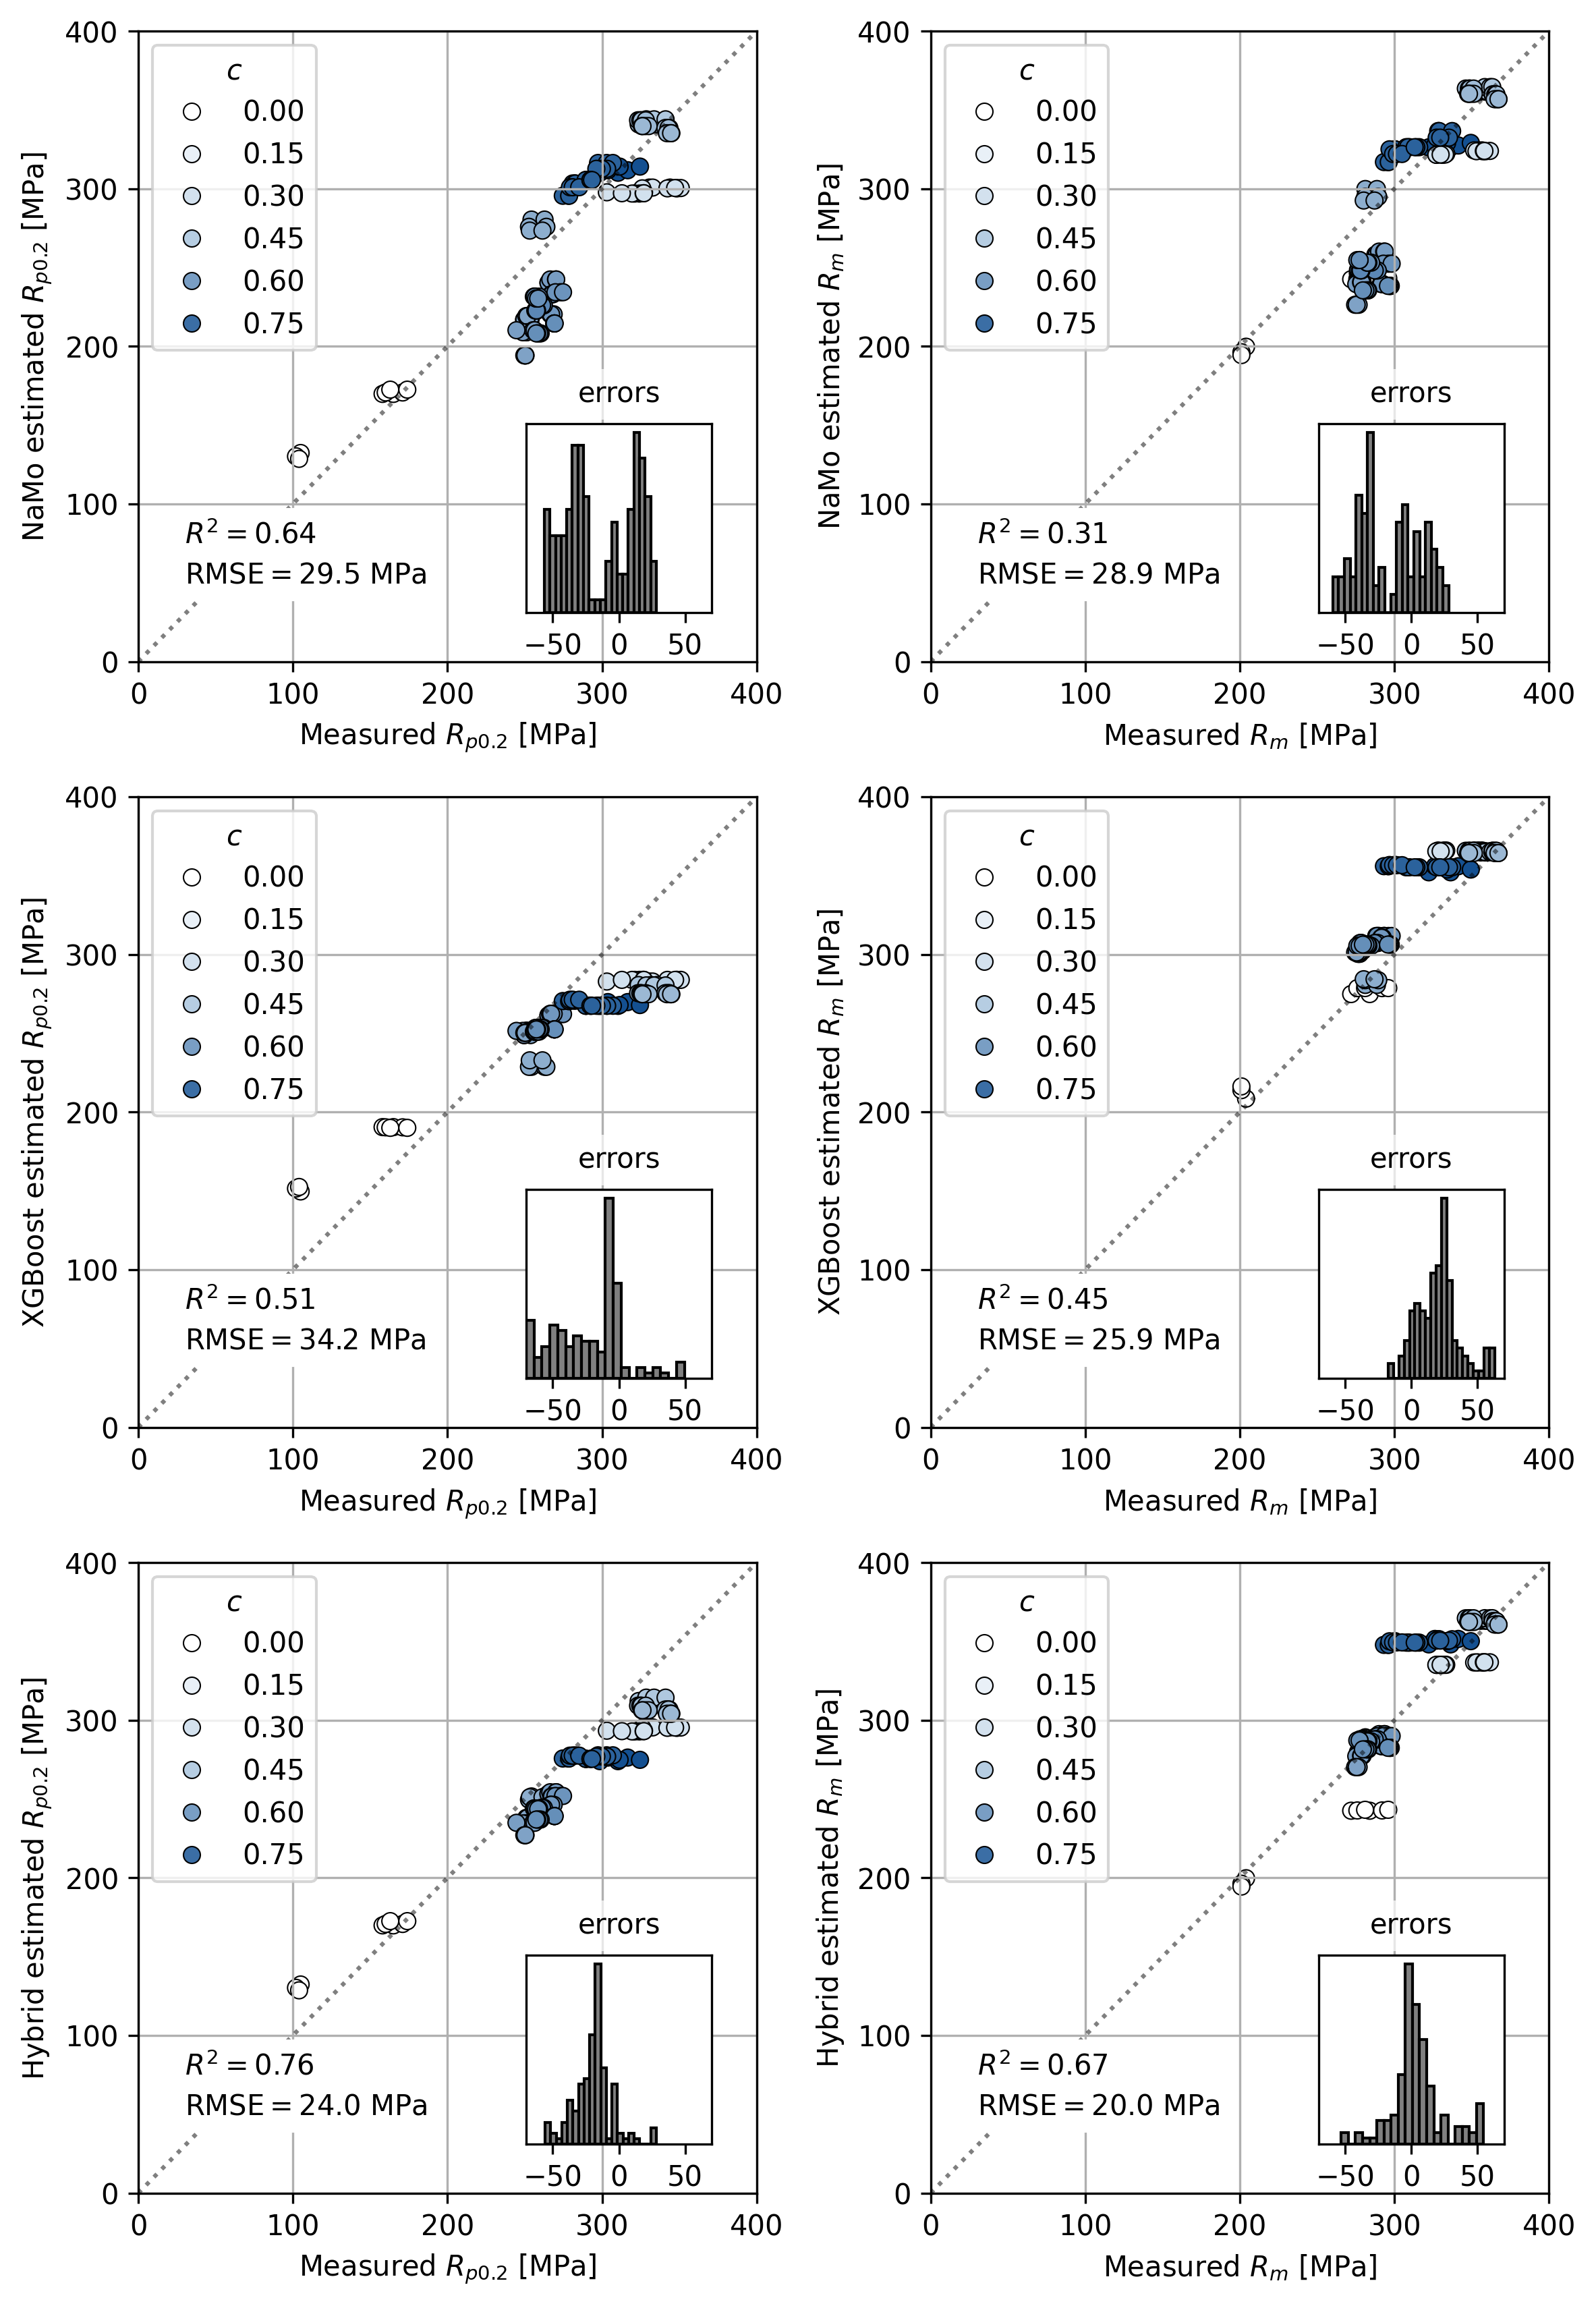

In [24]:
fig, [[ax1, ax2], [ax3, ax4], [ax5, ax6]] = plt.subplots(3, 2, figsize=(8, 11.5))

model_eval_plot_hue(df_example, "Rp0.2 [MPa]", "NaMo Rp02", "coeff", "Measured $R_{p0.2}$ [MPa]", "NaMo estimated $R_{p0.2}$ [MPa]", ax1)
model_eval_plot_hue(df_example, "Rm [MPa]", "NaMo Rm", "coeff", "Measured $R_m$ [MPa]", "NaMo estimated $R_m$ [MPa]", ax2)

model_eval_plot_hue(df_example, "Rp0.2 [MPa]", "XGB Rp02", "coeff", "Measured $R_{p0.2}$ [MPa]", "XGBoost estimated $R_{p0.2}$ [MPa]", ax3)
model_eval_plot_hue(df_example, "Rm [MPa]", "XGB Rm", "coeff", "Measured $R_m$ [MPa]", "XGBoost estimated $R_m$ [MPa]", ax4)

model_eval_plot_hue(df_example, "Rp0.2 [MPa]", "Hybrid Rp02", "coeff", "Measured $R_{p0.2}$ [MPa]", "Hybrid estimated $R_{p0.2}$ [MPa]", ax5)
model_eval_plot_hue(df_example, "Rm [MPa]", "Hybrid Rm", "coeff", "Measured $R_m$ [MPa]", "Hybrid estimated $R_m$ [MPa]", ax6)

plt.tight_layout()

## Random-seed robustness evaluation

Repeat XGBoost and hybrid inference across several random seeds to quantify sensitivity to model initialization. This evaluates the stability of the hybrid model behavior, i.e. hybrid model robustness.

NB: This takes 10-15 minutes on a typical laptop

In [ ]:
from joblib import Parallel, delayed
import os

N_REPEATS = 1000
N_JOBS = max(1, (os.cpu_count() or 2) - 1)

y_true = df_d3[Y_COLS].to_numpy(dtype=float)
namo_pred = df_d3[["NaMo Rp02", "NaMo Rm"]].to_numpy(dtype=float)
coeff = df_d3["coeff"].to_numpy(dtype=float)[:, None]

target_names = ["$R_{p0.2}$", "$R_{m}$"]


def rmse_vec(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2, axis=0))


def r2_vec(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2, axis=0)
    ss_tot = np.sum((y_true - y_true.mean(axis=0)) ** 2, axis=0)
    return 1 - ss_res / ss_tot


namo_rmse = rmse_vec(y_true, namo_pred)
namo_r2 = r2_vec(y_true, namo_pred)


def metrics_from_arrays(xgb_pred):
    hybrid_pred = xgb_pred * coeff + namo_pred * (1 - coeff)

    xgb_rmse = rmse_vec(y_true, xgb_pred)
    xgb_r2 = r2_vec(y_true, xgb_pred)
    hybrid_rmse = rmse_vec(y_true, hybrid_pred)
    hybrid_r2 = r2_vec(y_true, hybrid_pred)

    return {
        "NaMo $R_{p0.2}$ RMSE": namo_rmse[0],
        "NaMo $R_{m}$ RMSE": namo_rmse[1],
        "NaMo $R_{p0.2}$ $R^2$": namo_r2[0],
        "NaMo $R_{m}$ $R^2$": namo_r2[1],
        "XGB $R_{p0.2}$ RMSE": xgb_rmse[0],
        "XGB $R_{m}$ RMSE": xgb_rmse[1],
        "XGB $R_{p0.2}$ $R^2$": xgb_r2[0],
        "XGB $R_{m}$ $R^2$": xgb_r2[1],
        "Hybrid $R_{p0.2}$ RMSE": hybrid_rmse[0],
        "Hybrid $R_{m}$ RMSE": hybrid_rmse[1],
        "Hybrid $R_{p0.2}$ $R^2$": hybrid_r2[0],
        "Hybrid $R_{m}$ $R^2$": hybrid_r2[1],
    }


def run_seed(seed):
    params = dict(XGB_PARAMS)
    params["random_state"] = seed

    # Important: use one XGBoost thread per process to avoid CPU oversubscription.
    params["n_jobs"] = 1

    reg = xgb.XGBRegressor(**params)
    reg.fit(X_train, y_train)

    xgb_pred = reg.predict(X_test)
    return seed, metrics_from_arrays(xgb_pred)


seed_results = Parallel(n_jobs=N_JOBS, prefer="processes")(
    delayed(run_seed)(seed) for seed in range(N_REPEATS)
)

seeds, results = zip(*seed_results)
results_df = pd.DataFrame(results, index=seeds).sort_index()
display(results_df.describe())


100%|██████████| 1000/1000 [11:39<00:00,  1.43it/s]


,NaMo $R_{p0.2}$ RMSE,NaMo $R_{m}$ RMSE,NaMo $R_{p0.2}$ $R^2$,NaMo $R_{m}$ $R^2$,XGB $R_{p0.2}$ RMSE,XGB $R_{m}$ RMSE,XGB $R_{p0.2}$ $R^2$,XGB $R_{m}$ $R^2$,Hybrid $R_{p0.2}$ RMSE,Hybrid $R_{m}$ RMSE,Hybrid $R_{p0.2}$ $R^2$,Hybrid $R_{m}$ $R^2$
count,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000
mean,29.484,28.873,0.636,0.315,32.345,24.563,0.559,0.496,24.766,18.442,0.741,0.719
std,0.000,0.000,0.000,0.000,2.993,3.106,0.083,0.128,2.218,1.306,0.047,0.040
min,29.484,28.873,0.636,0.315,25.437,16.495,0.225,-0.088,18.967,15.210,0.548,0.540
25%,29.484,28.873,0.636,0.315,30.293,22.315,0.512,0.419,23.255,17.509,0.714,0.695
50%,29.484,28.873,0.636,0.315,31.908,24.548,0.574,0.505,24.598,18.434,0.747,0.721
75%,29.484,28.873,0.636,0.315,34.163,26.592,0.616,0.591,26.156,19.250,0.774,0.748
max,29.484,28.873,0.636,0.315,43.034,36.375,0.729,0.776,32.883,23.650,0.850,0.810


## 10. Performance summary

Summarize RMSE and R² distributions for NaMo, XGBoost, and the hybrid model across random seeds.

In [19]:
summary_rows = []
for model in ["NaMo", "XGB", "Hybrid"]:
    for prop_label, rmse_col, r2_col in [
        ("Rp0.2 [MPa]", f"{model} $R_{{p0.2}}$ RMSE", f"{model} $R_{{p0.2}}$ $R^2$"),
        ("Rm [MPa]", f"{model} $R_{{m}}$ RMSE", f"{model} $R_{{m}}$ $R^2$"),
    ]:
        summary_rows.append({
            "model": model,
            "target": prop_label,
            "RMSE mean": results_df[rmse_col].mean(),
            "RMSE std": results_df[rmse_col].std(),
            "R2 mean": results_df[r2_col].mean(),
            "R2 std": results_df[r2_col].std(),
        })

performance_summary = pd.DataFrame(summary_rows)
display(performance_summary)

,model,target,RMSE mean,RMSE std,R2 mean,R2 std
0,NaMo,Rp0.2 [MPa],29.484,0.000,0.636,0.000
1,NaMo,Rm [MPa],28.873,0.000,0.315,0.000
2,XGB,Rp0.2 [MPa],32.345,2.993,0.559,0.083
3,XGB,Rm [MPa],24.563,3.106,0.496,0.128
4,Hybrid,Rp0.2 [MPa],24.766,2.218,0.741,0.047
5,Hybrid,Rm [MPa],18.442,1.306,0.719,0.040


## 11. Metric distributions

Plot the seed-to-seed distributions of model performance metrics for both tensile-property targets.

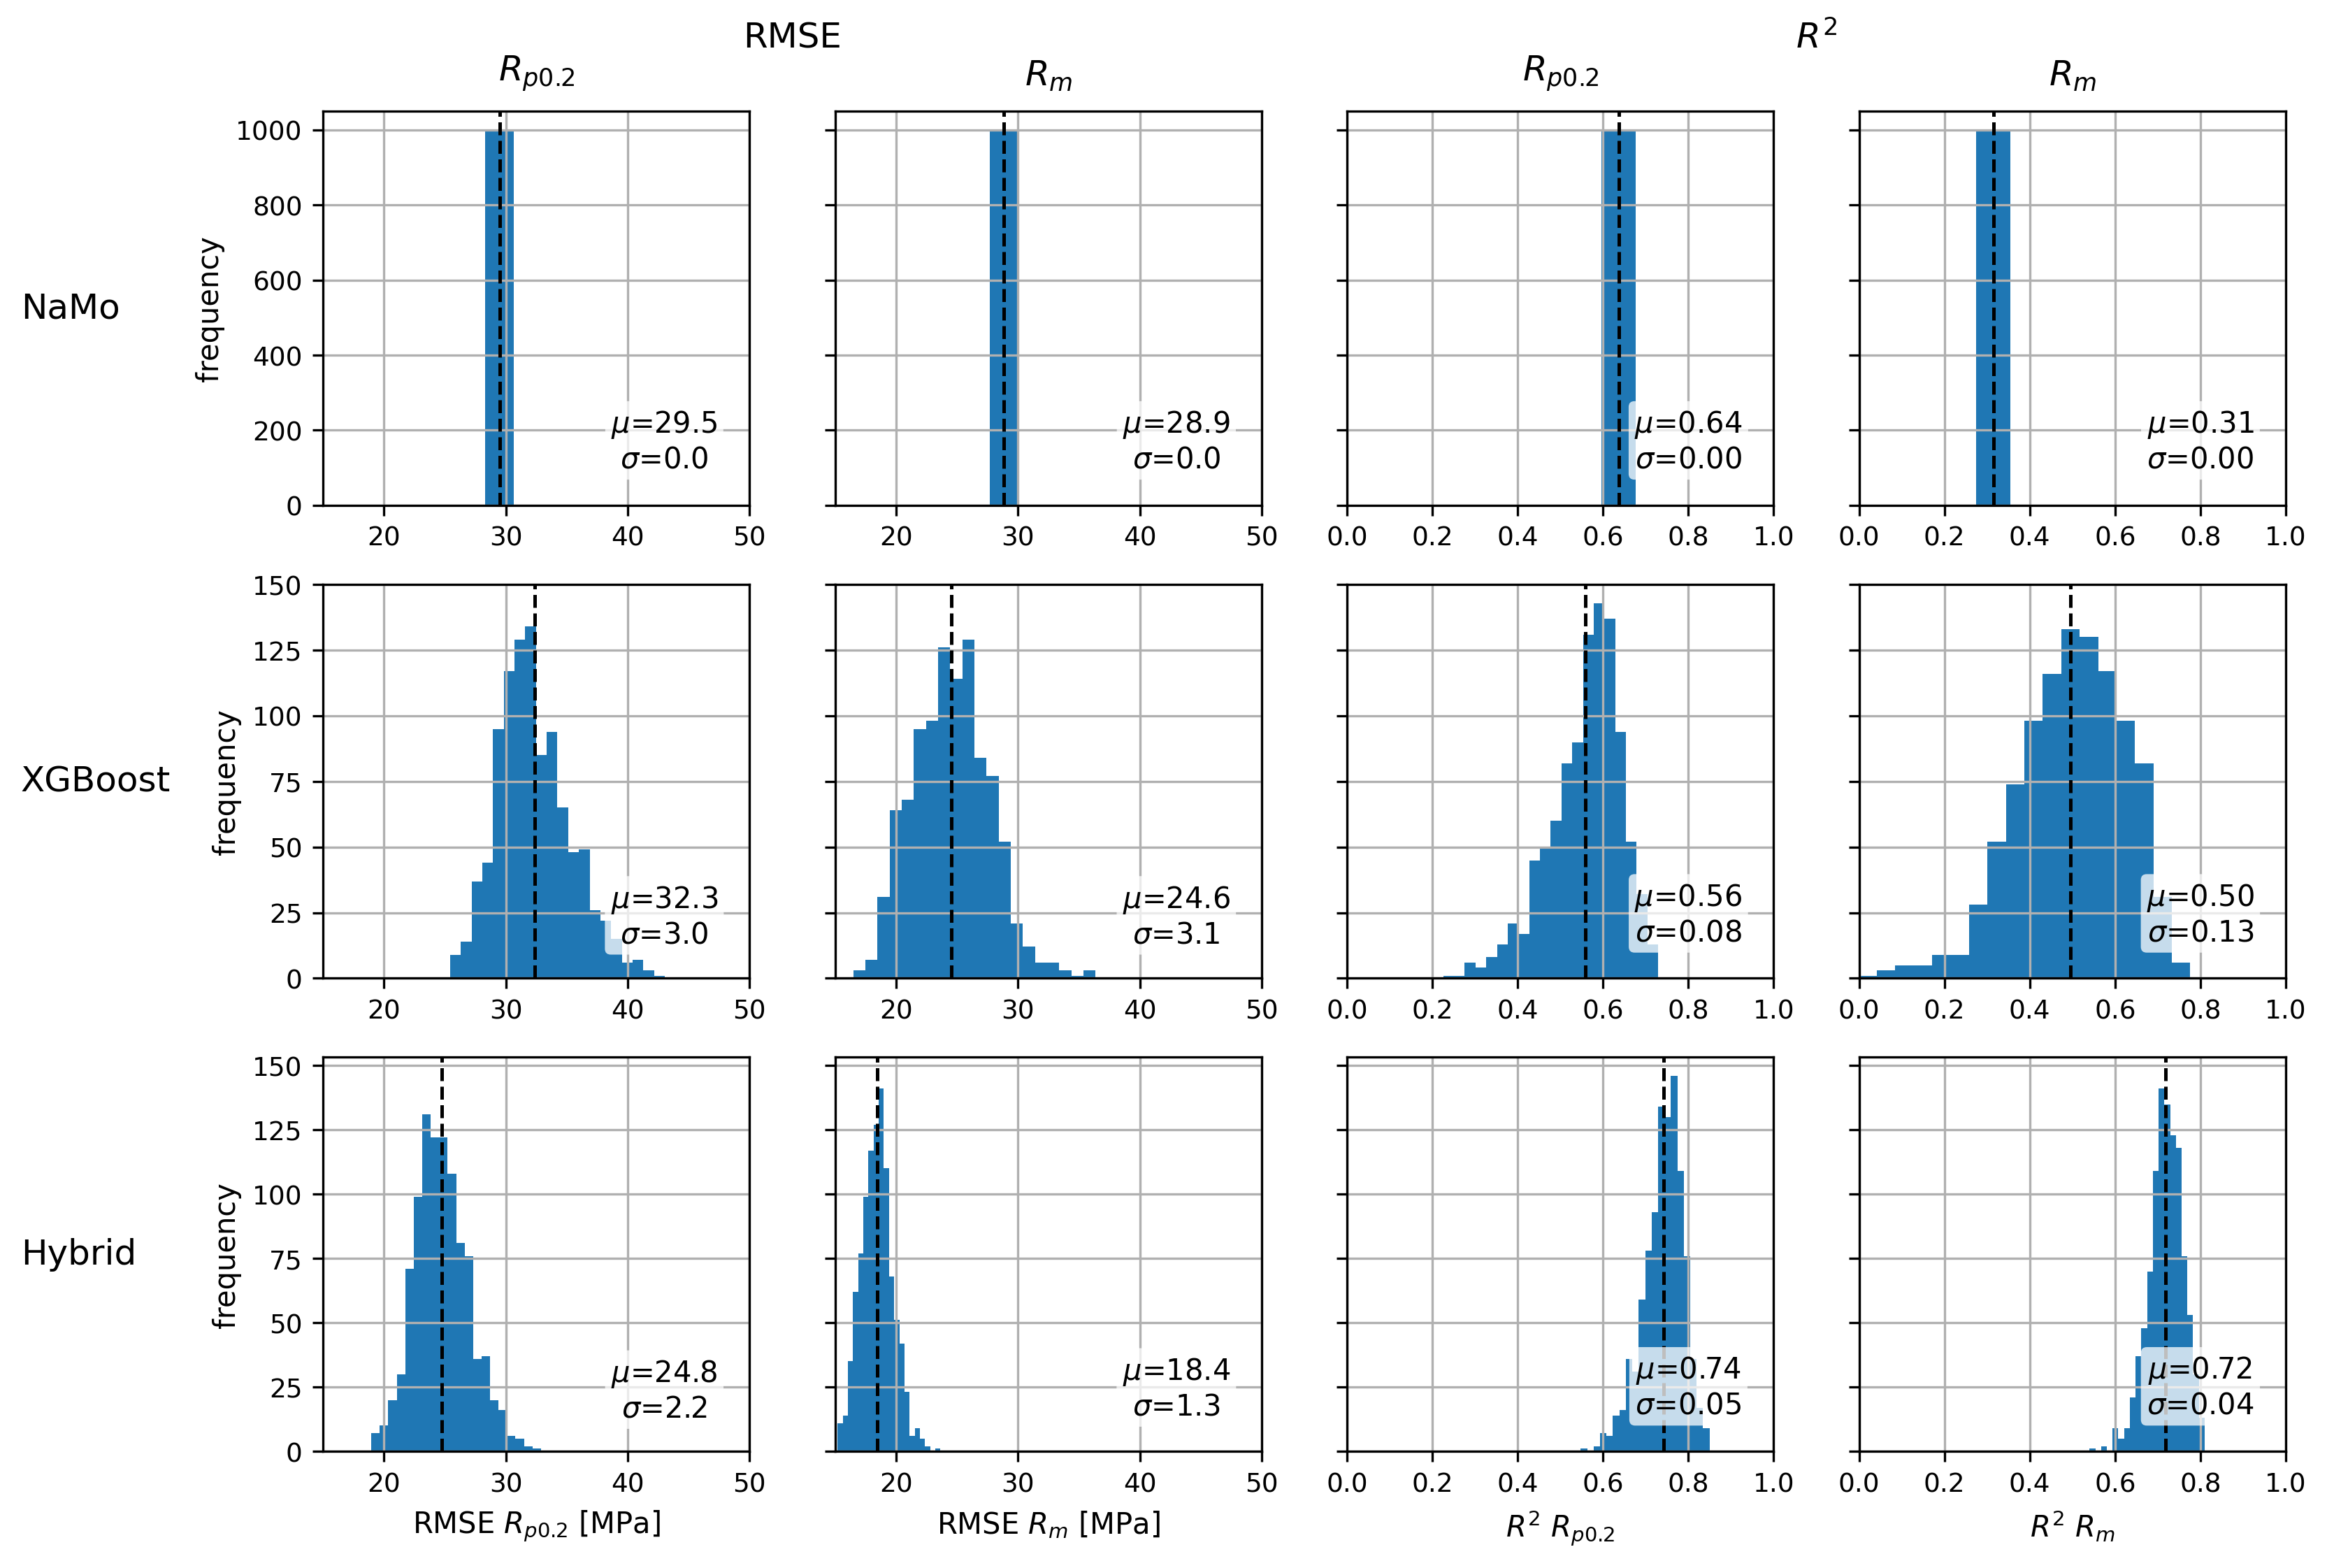

In [20]:
cols = list(results_df.columns)
fig, axes = plt.subplots(3, 4, figsize=(12, 9), sharey="row")
for i in range(3):
    for j in range(4):
        ax = axes[i, j]
        col_idx = i * 4 + j
        col = cols[col_idx]
        results_df[col].hist(ax=ax, color="C0", edgecolor="none", bins=20)
        ax.tick_params(axis="both", which="major", labelsize=9)
        if "RMSE" in col:
            ax.set_xlim(15, 50)
        else:
            ax.set_xlim(0, 1)
        mean = results_df[col].mean()
        ax.axvline(mean, color="k", linestyle="dashed", linewidth=1.2)
        ylim = ax.get_ylim()
        xlim = ax.get_xlim()
        y_text = ylim[1] * 0.08
        x_text = xlim[1] - (xlim[1] - xlim[0]) * 0.2
        y_arrow = ylim[1] * 0.35
        if "RMSE" in col:
            text = f"$\\mu$={mean:0.1f}\n$\\sigma$={results_df[col].std():0.1f}"
        else:
            text = f"$\\mu$={mean:0.2f}\n$\\sigma$={results_df[col].std():0.2f}"
        ax.annotate(text, xy=(mean, y_arrow), xytext=(x_text, y_text), ha="center", va="bottom", fontsize=10,
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.75))
        if results_df[col].nunique() <= 1:
            value = results_df[col].iloc[0]
            for p in list(ax.patches):
                p.remove()
            x0, x1 = ax.get_xlim()
            width = max((x1 - x0) / 15.0, 0.08)
            ax.bar(value, len(results_df), width=width, align="center", color="C0")
            top = max(ax.get_ylim()[1], len(results_df) * 1.05)
            ax.set_ylim(0, top)

for i in range(3):
    axes[i, 0].set_ylabel("frequency", fontsize=10)

x_labels = ["RMSE $R_{p0.2}$ [MPa]", "RMSE $R_m$ [MPa]", "$R^2$ $R_{p0.2}$", "$R^2$ $R_m$"]
for j, lab in enumerate(x_labels):
    axes[2, j].set_xlabel(lab, fontsize=10)

fig.subplots_adjust(top=0.82, left=0.12)
pos00 = axes[0, 0].get_position()
pos01 = axes[0, 1].get_position()
pos02 = axes[0, 2].get_position()
pos03 = axes[0, 3].get_position()
rmse_center = (pos00.x0 + pos01.x1) / 2
r2_center = (pos02.x0 + pos03.x1) / 2
y_ref = 0.85
fig.text(rmse_center, y_ref, "RMSE", ha="center", va="bottom", fontsize=12)
fig.text(r2_center, y_ref, "$R^2$", ha="center", va="bottom", fontsize=12)
fig.text((pos00.x0 + pos00.x1) / 2, y_ref - 0.02, "$R_{p0.2}$", ha="center", va="bottom", fontsize=12)
fig.text((pos01.x0 + pos01.x1) / 2, y_ref - 0.02, "$R_m$", ha="center", va="bottom", fontsize=12)
fig.text((pos02.x0 + pos02.x1) / 2, y_ref - 0.02, "$R_{p0.2}$", ha="center", va="bottom", fontsize=12)
fig.text((pos03.x0 + pos03.x1) / 2, y_ref - 0.02, "$R_m$", ha="center", va="bottom", fontsize=12)

row_labels = ["NaMo", "XGBoost", "Hybrid"]
for i, lab in enumerate(row_labels):
    pos = axes[i, 0].get_position()
    y_center = (pos.y0 + pos.y1) / 2
    fig.text(0.0, y_center, lab, ha="left", va="center", fontsize=12)


## 12. Hybrid win-rate counts

Calculate the hybrid win-rate, i.e. how often it outperforms NaMo and XGBoost across random seeds and target properties.

In [21]:
total_count = len(results_df)
hyb_rp02_better_than_xgb_and_namo_rmse = ((results_df["Hybrid $R_{p0.2}$ RMSE"] < results_df["XGB $R_{p0.2}$ RMSE"]) & (results_df["Hybrid $R_{p0.2}$ RMSE"] < results_df["NaMo $R_{p0.2}$ RMSE"])).sum()
hyb_rm_better_than_xgb_and_namo_rmse = ((results_df["Hybrid $R_{m}$ RMSE"] < results_df["XGB $R_{m}$ RMSE"]) & (results_df["Hybrid $R_{m}$ RMSE"] < results_df["NaMo $R_{m}$ RMSE"])).sum()
hyb_rp02_better_than_xgb_and_namo_r2 = ((results_df["Hybrid $R_{p0.2}$ $R^2$"] > results_df["XGB $R_{p0.2}$ $R^2$"]) & (results_df["Hybrid $R_{p0.2}$ $R^2$"] > results_df["NaMo $R_{p0.2}$ $R^2$"])).sum()
hyb_rm_better_than_xgb_and_namo_r2 = ((results_df["Hybrid $R_{m}$ $R^2$"] > results_df["XGB $R_{m}$ $R^2$"]) & (results_df["Hybrid $R_{m}$ $R^2$"] > results_df["NaMo $R_{m}$ $R^2$"])).sum()
print(f"Hybrid Rp02 RMSE is better than both XGB and NaMo in {hyb_rp02_better_than_xgb_and_namo_rmse}/{total_count} runs ({hyb_rp02_better_than_xgb_and_namo_rmse/total_count*100:.1f}%)")
print(f"Hybrid Rm RMSE is better than both XGB and NaMo in {hyb_rm_better_than_xgb_and_namo_rmse}/{total_count} runs ({hyb_rm_better_than_xgb_and_namo_rmse/total_count*100:.1f}%)")
print(f"Hybrid Rp02 R2 is better than both XGB and NaMo in {hyb_rp02_better_than_xgb_and_namo_r2}/{total_count} runs ({hyb_rp02_better_than_xgb_and_namo_r2/total_count*100:.1f}%)")
print(f"Hybrid Rm R2 is better than both XGB and NaMo in {hyb_rm_better_than_xgb_and_namo_r2}/{total_count} runs ({hyb_rm_better_than_xgb_and_namo_r2/total_count*100:.1f}%)")

hyb_better_than_xgb_rp02_rmse = (results_df["Hybrid $R_{p0.2}$ RMSE"] < results_df["XGB $R_{p0.2}$ RMSE"]).sum()
hyb_better_than_xgb_rm_rmse = (results_df["Hybrid $R_{m}$ RMSE"] < results_df["XGB $R_{m}$ RMSE"]).sum()
hyb_better_than_xgb_rp02_r2 = (results_df["Hybrid $R_{p0.2}$ $R^2$"] > results_df["XGB $R_{p0.2}$ $R^2$"]).sum()
hyb_better_than_xgb_rm_r2 = (results_df["Hybrid $R_{m}$ $R^2$"] > results_df["XGB $R_{m}$ $R^2$"]).sum()
print(f"Hybrid Rp02 RMSE is better than XGB in {hyb_better_than_xgb_rp02_rmse}/{total_count} runs ({hyb_better_than_xgb_rp02_rmse/total_count*100:.1f}%)")
print(f"Hybrid Rm RMSE is better than XGB in {hyb_better_than_xgb_rm_rmse}/{total_count} runs ({hyb_better_than_xgb_rm_rmse/total_count*100:.1f}%)")
print(f"Hybrid Rp02 R2 is better than XGB in {hyb_better_than_xgb_rp02_r2}/{total_count} runs ({hyb_better_than_xgb_rp02_r2/total_count*100:.1f}%)")
print(f"Hybrid Rm R2 is better than XGB in {hyb_better_than_xgb_rm_r2}/{total_count} runs ({hyb_better_than_xgb_rm_r2/total_count*100:.1f}%)")

Hybrid Rp02 RMSE is better than both XGB and NaMo in 972/1000 runs (97.2%)
Hybrid Rm RMSE is better than both XGB and NaMo in 963/1000 runs (96.3%)
Hybrid Rp02 R2 is better than both XGB and NaMo in 972/1000 runs (97.2%)
Hybrid Rm R2 is better than both XGB and NaMo in 963/1000 runs (96.3%)
Hybrid Rp02 RMSE is better than XGB in 1000/1000 runs (100.0%)
Hybrid Rm RMSE is better than XGB in 963/1000 runs (96.3%)
Hybrid Rp02 R2 is better than XGB in 1000/1000 runs (100.0%)
Hybrid Rm R2 is better than XGB in 963/1000 runs (96.3%)


## 13. Error versus coefficient

Bin D3 predictions by hybrid coefficient and compare XGBoost and hybrid errors within each coefficient range.

This checks whether the coefficient is informative as a local trust indicator under domain shift.

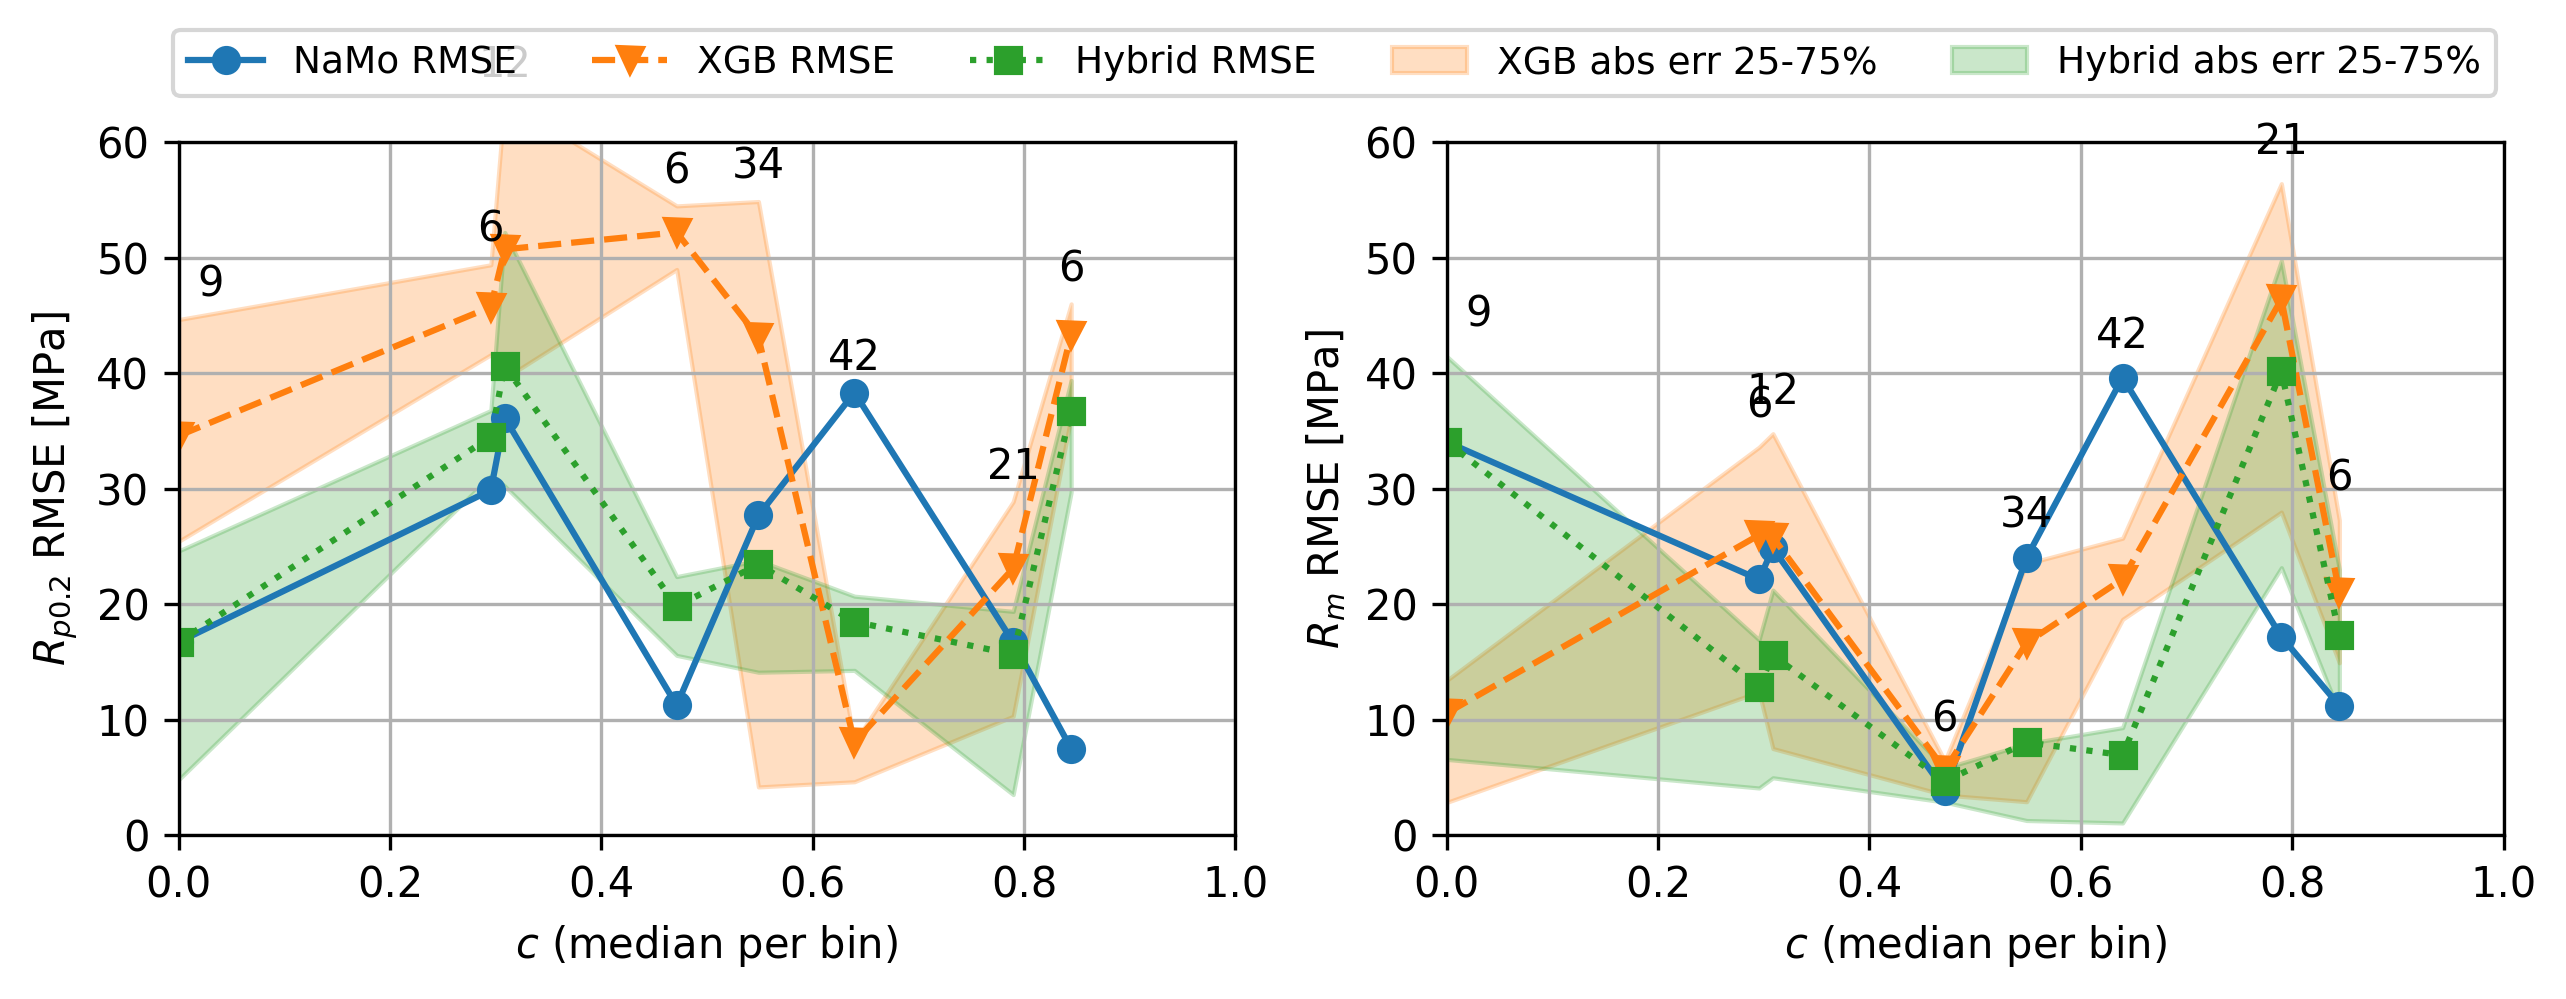

In [ ]:
# Bins with fixed interval 0.1 and show per-bin RMSE + 25-75% bands for XGB and Hybrid
bin_width = 0.1
df_cal = df_example.copy()
min_c = df_cal["coeff"].min()
max_c = df_cal["coeff"].max()
min_floor = np.floor(min_c / bin_width) * bin_width
max_ceil = np.ceil(max_c / bin_width) * bin_width
bins = np.arange(min_floor, max_ceil + bin_width / 2, bin_width)
df_cal["coeff_bin"] = pd.cut(df_cal["coeff"], bins=bins, include_lowest=True)
groups = []
for b, g in df_cal.groupby("coeff_bin"):
    if g.shape[0] == 0:
        continue
    coeff_center = g["coeff"].median()
    rp_xgb = rmse(g["Rp0.2 [MPa]"], g["XGB Rp02"])
    rp_hyb = rmse(g["Rp0.2 [MPa]"], g["Hybrid Rp02"])
    rp_namo = rmse(g["Rp0.2 [MPa]"], g["NaMo Rp02"])
    rp_abs_xgb = np.abs(g["XGB Rp02"] - g["Rp0.2 [MPa]"])
    rp_q25_xgb, rp_q75_xgb = np.quantile(rp_abs_xgb, [0.25, 0.75])
    rp_abs_hyb = np.abs(g["Hybrid Rp02"] - g["Rp0.2 [MPa]"])
    rp_q25_hyb, rp_q75_hyb = np.quantile(rp_abs_hyb, [0.25, 0.75])
    rm_xgb = rmse(g["Rm [MPa]"], g["XGB Rm"])
    rm_hyb = rmse(g["Rm [MPa]"], g["Hybrid Rm"])
    rm_namo = rmse(g["Rm [MPa]"], g["NaMo Rm"])
    rm_abs_xgb = np.abs(g["XGB Rm"] - g["Rm [MPa]"])
    rm_q25_xgb, rm_q75_xgb = np.quantile(rm_abs_xgb, [0.25, 0.75])
    rm_abs_hyb = np.abs(g["Hybrid Rm"] - g["Rm [MPa]"])
    rm_q25_hyb, rm_q75_hyb = np.quantile(rm_abs_hyb, [0.25, 0.75])
    groups.append({
        "bin": str(b),
        "coeff": coeff_center,
        "Rp0.2_XGB_RMSE": rp_xgb,
        "Rp0.2_Hybrid_RMSE": rp_hyb,
        "Rp0.2_NaMo_RMSE": rp_namo,
        "Rp0.2_q25_xgb": rp_q25_xgb,
        "Rp0.2_q75_xgb": rp_q75_xgb,
        "Rp0.2_q25_hyb": rp_q25_hyb,
        "Rp0.2_q75_hyb": rp_q75_hyb,
        "Rm_XGB_RMSE": rm_xgb,
        "Rm_Hybrid_RMSE": rm_hyb,
        "Rm_NaMo_RMSE": rm_namo,
        "Rm_q25_xgb": rm_q25_xgb,
        "Rm_q75_xgb": rm_q75_xgb,
        "Rm_q25_hyb": rm_q25_hyb,
        "Rm_q75_hyb": rm_q75_hyb,
        "count": g.shape[0],
    })
cal_df = pd.DataFrame(groups).sort_values("coeff")

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
ax = axes[0]
ax.plot(cal_df["coeff"], cal_df["Rp0.2_NaMo_RMSE"], label="NaMo RMSE", marker="o")
ax.plot(cal_df["coeff"], cal_df["Rp0.2_XGB_RMSE"], label="XGB RMSE", linestyle="--", marker="v")
ax.plot(cal_df["coeff"], cal_df["Rp0.2_Hybrid_RMSE"], label="Hybrid RMSE", linestyle=":", marker="s")
ax.fill_between(cal_df["coeff"], cal_df["Rp0.2_q25_xgb"], cal_df["Rp0.2_q75_xgb"], color="C1", alpha=0.25, label="XGB abs err 25-75%")
ax.fill_between(cal_df["coeff"], cal_df["Rp0.2_q25_hyb"], cal_df["Rp0.2_q75_hyb"], color="C2", alpha=0.25, label="Hybrid abs err 25-75%")
ax.set_xlabel("$c$ (median per bin)")
ax.set_ylabel("$R_{p0.2}$ RMSE [MPa]")

ax = axes[1]
ax.plot(cal_df["coeff"], cal_df["Rm_NaMo_RMSE"], label="NaMo RMSE", marker="o")
ax.plot(cal_df["coeff"], cal_df["Rm_XGB_RMSE"], label="XGB RMSE", linestyle="--", marker="v")
ax.plot(cal_df["coeff"], cal_df["Rm_Hybrid_RMSE"], label="Hybrid RMSE", linestyle=":", marker="s")
ax.fill_between(cal_df["coeff"], cal_df["Rm_q25_xgb"], cal_df["Rm_q75_xgb"], color="C1", alpha=0.25, label="XGB abs err 25-75%")
ax.fill_between(cal_df["coeff"], cal_df["Rm_q25_hyb"], cal_df["Rm_q75_hyb"], color="C2", alpha=0.25, label="Hybrid abs err 25-75%")
ax.set_xlabel("$c$ (median per bin)")
ax.set_ylabel("$R_m$ RMSE [MPa]")

handles, labels = ax.get_legend_handles_labels()
pos = ax.get_position()
x_fig = pos.x1 * 0.13
y_fig = pos.y1 * 1.1
legend = fig.legend(handles, labels, fontsize=9, ncol=5,
                    bbox_to_anchor=(x_fig, y_fig),
                    loc="center left")

[ax.grid(True) for ax in axes]
[ax.set_ylim(0, 60) for ax in axes]
[ax.set_xlim(0, 1) for ax in axes]
y0_0, y1_0 = axes[0].get_ylim()
yrange0 = y1_0 - y0_0
y0_1, y1_1 = axes[1].get_ylim()
yrange1 = y1_1 - y0_1
for i in range(len(cal_df)):
    x_val = cal_df["coeff"].iloc[i]
    if x_val < 0.03:
        x_val = 0.03
    cnt = int(cal_df["count"].iloc[i])
    if cnt <= 0:
        continue
    vals = [cal_df["Rp0.2_NaMo_RMSE"].iloc[i], cal_df["Rp0.2_XGB_RMSE"].iloc[i], cal_df["Rp0.2_Hybrid_RMSE"].iloc[i], cal_df["Rp0.2_q75_xgb"].iloc[i], cal_df["Rp0.2_q75_hyb"].iloc[i]]
    y_max_bin = np.nanmax(vals)
    y_text0 = y_max_bin + 0.02 * yrange1
    axes[0].text(x_val, y_text0, str(cnt), ha="center", va="bottom", fontsize=10, color="black")
    vals2 = [cal_df["Rm_NaMo_RMSE"].iloc[i], cal_df["Rm_XGB_RMSE"].iloc[i], cal_df["Rm_Hybrid_RMSE"].iloc[i], cal_df["Rm_q75_xgb"].iloc[i], cal_df["Rm_q75_hyb"].iloc[i]]
    y_max_bin2 = np.nanmax(vals2)
    y_text1 = y_max_bin2 + 0.03 * yrange1
    axes[1].text(x_val, y_text1, str(cnt), ha="center", va="bottom", fontsize=10, color="black")

# plt.tight_layout()